# Setup

In [2]:
import pathlib
import sys
sys.path.insert(1, "/Users/ian.convy/code/mmvaeplus/src")
import models as mmvae_models
sys.path.insert(1, "/Users/ian.convy/code/model_compare")
import utils_mmvae

import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)

import utils
from data import MET_Data
from losses import ReconstructionLoss

# Data

In [17]:
data_config = {
    "patchseq": {
        "path": "../../data/neurons.hdf5",
        "keys": {
            "logcpm": "logcpm", 
            "pca-ipfx": "pca-ipfx", 
            "arbors": "arbors"
        },
        "query": {"formats": [("logcpm", "pca-ipfx", "arbors")]},
        "modal_forms": {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"},
        "exclude": []
    },
    "polymnist": {
        "path": "../../data/polymnist.hdf5",
        "keys": {
            "m0": "m0",
            "m1": "m1",
            "m2": "m2",
            "m3": "m3",
            "m4": "m4",
        },
        "query": {},
        "modal_forms": {"A": "m0", "B": "m1", "C": "m2", "D": "m3", "E": "m4"},
        "exclude": []
    },
    "cub": {
        "path": "../../data/cub.hdf5",
        "keys": {
            "images": "images",
            "captions": "captions"
        },
        "query": {},
        "modal_forms": {"A": "images", "B": "captions"},
        "exclude": ["B"]
    }
}
datasets = {name: MET_Data(config["path"], **config["keys"]) for (name, config) in data_config.items()}

# Models

In [5]:
models = {}

## Ours

### Patch-seq

In [20]:
model_path = pathlib.Path("../../results/baselines/met")
model_dict = utils.load_jit_folds(model_path)
modals = ["T", "E", "M"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model, output_modals = modals):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        output = model(X_tensors, input_modal, output_modals)
        return output
    folds[fold] = {
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("patchseq", {})["ours"] = folds


### PolyMNIST

In [7]:
model_path = pathlib.Path("../../results/polymnist/64_recon_10")
model_dict = utils.load_jit_folds(model_path)
modals = ["A", "B", "C", "D", "E"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model, output_modals = modals):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        output = model(X_tensors, input_modal, output_modals)
        return output
    folds[fold] = {
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("polymnist", {})["ours"] = folds


### CUB

In [8]:
model_path = pathlib.Path("../../results/cub/64_recon_10")
model_dict = utils.load_jit_folds(model_path)
modals = ["A", "B"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model, output_modals = modals):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        output = model(X_tensors, input_modal, output_modals)
        return output
    folds[fold] = {
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("cub", {})["ours"] = folds


## MMVAE+

### Patch-seq

In [27]:
folds = {}
modal_forms = {"T": "logcpm", "H": "pca-ipfx", "M": "arbors"}
model_dict = utils_mmvae.load_jit_folds("/Users/ian.convy/code/model_compare/results/patchseq/5_5_met")
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model, modal_forms = modal_forms):
        input_modal = "H" if input_modal == "E" else input_modal
        recons = {}
        X = X_dict[modal_forms[input_modal]]
        X_tensor = torch.from_numpy(X).float()
        (qz_x, qw_x, z, outputs) = model(X_tensor, input_modal, list(modal_forms), 1, freeze_w = True, freeze_z = True)
        for (out_modal, (px_u, _)) in outputs.items():
            recons.setdefault(out_modal, {})[modal_forms[out_modal]] = px_u.mean[0]
        recons["E"] = recons.pop("H")
        return recons
    folds[fold] = {
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": ["T", "E", "M"]
    }
models.setdefault("patchseq", {})["mmvae"] = folds

### PolyMNIST

In [29]:
folds = {}
modal_forms = {"A": "m0", "B": "m1", "C": "m2", "D": "m3", "E": "m4"}
model_dict = utils_mmvae.load_jit_folds("/Users/ian.convy/code/model_compare/results/polymnist/32_32")
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model, modal_forms = modal_forms):
        recons = {}
        X = X_dict[modal_forms[input_modal]]
        X_tensor = torch.from_numpy(X).float().permute(0, 3, 1, 2).contiguous()
        (qz_x, qw_x, z, outputs) = model(X_tensor, input_modal, list(modal_forms), 1, freeze_w = True, freeze_z = True)
        for (out_modal, (px_u, _)) in outputs.items():
            recons.setdefault(out_modal, {})[modal_forms[out_modal]] = px_u.mean[0].permute(0, 2, 3, 1)
        return recons
    folds[fold] = {
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": list(modal_forms)
    }
models.setdefault("polymnist", {})["mmvae"] = folds

### CUB

In [11]:
folds = {}
modal_indices = {"A": 0, "B": 1}
modal_forms = data_config["cub"]["modal_forms"]
mm_cub_path = "/Users/ian.convy/code/mmvaeplus/outputs/CUB_Image_Captions_1/checkpoints/16_48_1.0_2/model_10.rar"
mm_cub_args = torch.load("/Users/ian.convy/code/mmvaeplus/outputs/CUB_Image_Captions_1/checkpoints/16_48_1.0_2/args.rar")
mm_cub_model = mmvae_models.MMVAEplus_CUB_Image_Captions(mm_cub_args)
mm_cub_model.load_state_dict(torch.load(mm_cub_path, map_location = torch.device("cpu")))
mm_cub_model.eval()
def func(X_dict, input_modal, model = mm_cub_model, modal_forms = modal_forms, modal_indices = modal_indices):
    recons = {}
    in_arr = X_dict[modal_forms[input_modal]]
    input_vae = model.vaes[modal_indices[input_modal]]
    if input_modal == "A":
        mm_z = input_vae(torch.from_numpy(in_arr).float().permute(0, 3, 1, 2).contiguous())[0].mean[None, ..., 16:]
    else:
        caption = torch.nn.functional.one_hot(torch.from_numpy(in_arr).long(), 1590)
        mm_z = input_vae(caption.float())[0].mean[None, ..., 16:]
    mm_w = model.pw(*model.pw_params).mean[None].expand(-1, mm_z.shape[1], -1)
    mm_latent = torch.cat([mm_w, mm_z], -1)
    for out_modal in ["A", "B"]:
        output_vae = model.vaes[modal_indices[out_modal]]
        if out_modal == "A":
            mm_recon = output_vae.px_u(*output_vae.dec(mm_latent)).mean.squeeze().permute(0, 2, 3, 1)
        else:
            mm_recon = output_vae.px_u(*output_vae.dec(mm_latent)).mean[0]
        recons.setdefault(out_modal, {})[modal_forms[out_modal]] = mm_recon
    return recons
cub_data = datasets["cub"]
test_ids = cub_data["specimen_id"][cub_data["train_test"] == "test"]
folds[1] = {
    "test_ids": np.char.strip(test_ids),
    "model": func,
    "modals": ["A", "B"]
}
models.setdefault("cub", {})["mmvae"] = folds

# R2

In [12]:
variances = {}
for (name, met_data) in datasets.items():
    samples = met_data.query(**data_config[name]["query"])
    variances[name] = {form: np.nanvar(samples[form], 0) for form in data_config[name]["keys"]}

In [30]:
max_count = 1000
num_batches = {"patchseq": 1, "polymnist": 2, "cub": 4}
mse = {}
for (dataset_name, dataset_models) in models.items():
    met_data = datasets[dataset_name]
    query = data_config[dataset_name]["query"]
    modal_forms = data_config[dataset_name]["modal_forms"]
    excluded = data_config[dataset_name]["exclude"]
    batches = num_batches[dataset_name]
    for (model_name, folds) in dataset_models.items():
        sample_count = 0
        for (fold, fold_dict) in folds.items():
            samples = met_data.query(fold_dict["test_ids"], **query, outputs = list(modal_forms.values()))
            samples = {key: arr[:max_count] for (key, arr) in samples.items()}
            if "captions" in samples:
                samples["captions"] = samples["captions"][:, 0]
            sample_count += len(next(iter(samples.values())))
            for i in range(batches):
                batch_samples = {form: arr[i::batches] for (form, arr) in samples.items()}
                for (in_modal, in_form) in modal_forms.items():
                    outputs = fold_dict["model"](batch_samples, in_modal)
                    for (out_modal, out_forms_dict) in outputs.items():
                        if out_modal not in excluded:
                            print(f"Running {model_name} on {dataset_name}: {in_modal} -> {out_modal} {fold}                     ", end = "\r")
                            (out_form, X_recon) = next(iter(out_forms_dict.items()))
                            X = batch_samples[out_form]
                            error = np.square(X - X_recon.numpy(force = True)).sum(0)
                            mse.setdefault(dataset_name, {}).setdefault(model_name, {}).setdefault(in_modal, {}).setdefault(out_modal, []).append(error)
        for (modal_1, modal_dict) in mse[dataset_name][model_name].items():
            for (modal_2, fold_list) in modal_dict.items():
                modal_dict[modal_2] = np.sum(fold_list, 0) / sample_count

## Combined

In [31]:
r2_scores = {}
for (dataset_name, all_models) in mse.items():
    r2_scores[dataset_name] = {}
    modal_forms = data_config[dataset_name]["modal_forms"]
    for (model, model_dict) in all_models.items():
        for (modal_1, modal_dict) in model_dict.items():
            for (modal_2, r2s) in modal_dict.items():
                var = variances[dataset_name][modal_forms[modal_2]].sum()
                mean_mse = r2s.sum()
                r2_scores[dataset_name].setdefault(f"{modal_1}->{modal_2}", {})[model] = 1 - mean_mse/var

### Patch-seq

In [32]:
pd.DataFrame(r2_scores["patchseq"]).round(3).astype("string").fillna("--")

,T->T,T->E,T->M,E->T,E->E,E->M,M->T,M->E,M->M
ours,0.381,0.461,0.343,0.291,0.48,0.156,0.226,0.282,0.733
mmvae,0.39,0.393,0.4,0.285,0.689,0.257,0.244,0.283,0.743


In [ ]:
pd.DataFrame(r2_scores["patchseq"]).round(3).astype("string").fillna("--")

,T->T,T->E,E->T,E->E
ours,0.466,0.494,0.369,0.828
mmvae,0.157,0.504,0.086,0.526


### PolyMNIST

In [14]:
pd.DataFrame(r2_scores["polymnist"]).round(3).astype("string").fillna("--")

,A->A,A->B,A->C,A->D,A->E,B->A,B->B,B->C,B->D,B->E,C->A,C->B,C->C,C->D,C->E,D->A,D->B,D->C,D->D,D->E,E->A,E->B,E->C,E->D,E->E
ours,0.3,-0.054,0.001,0.011,-0.006,-0.034,0.161,0.001,0.011,-0.006,-0.048,-0.11,0.001,0.011,-0.006,-0.042,-0.111,0.001,0.012,-0.006,-0.047,-0.112,0.001,0.011,-0.006
mmvae,0.388,0.02,-0.021,-0.095,-0.036,-0.084,0.024,-0.021,-0.094,-0.035,-0.085,0.021,-0.009,-0.093,-0.036,-0.091,0.018,-0.024,-0.074,-0.036,-0.085,0.02,-0.021,-0.094,-0.034


In [ ]:
pd.DataFrame(r2_scores["polymnist"]).round(3).astype("string").fillna("--")

,A->A,A->B,A->C,A->D,A->E,B->A,B->B,B->C,B->D,B->E,C->A,C->B,C->C,C->D,C->E,D->A,D->B,D->C,D->D,D->E,E->A,E->B,E->C,E->D,E->E
ours,0.3,-0.054,0.001,0.011,-0.006,-0.034,0.161,0.001,0.011,-0.006,-0.048,-0.11,0.001,0.011,-0.006,-0.042,-0.111,0.001,0.012,-0.006,-0.047,-0.112,0.001,0.011,-0.006
mmvae,0.388,0.018,-0.023,-0.099,-0.036,-0.083,0.025,-0.022,-0.096,-0.036,-0.085,0.021,-0.007,-0.096,-0.036,-0.091,0.017,-0.025,-0.074,-0.036,-0.085,0.02,-0.022,-0.097,-0.034


In [ ]:
pd.DataFrame(r2_scores["polymnist"]).round(3).astype("string").fillna("--")

,A->A,A->B,A->C,A->D,A->E,B->A,B->B,B->C,B->D,B->E,C->A,C->B,C->C,C->D,C->E,D->A,D->B,D->C,D->D,D->E,E->A,E->B,E->C,E->D,E->E
ours,0.763,0.024,0.016,0.051,-0.005,-0.004,0.806,0.021,0.064,-0.005,-0.004,0.034,0.784,0.066,-0.005,-0.004,0.028,0.018,0.685,-0.006,-0.004,0.021,0.013,0.045,0.796
mmvae,0.388,0.019,-0.023,-0.099,-0.036,-0.085,0.025,-0.022,-0.096,-0.036,-0.085,0.021,-0.007,-0.096,-0.036,-0.093,0.017,-0.025,-0.074,-0.036,-0.085,0.02,-0.022,-0.097,-0.034


### CUB

In [62]:
pd.DataFrame(r2_scores["cub"]).round(3).astype("string").fillna("--")

,A->A,B->A
ours,0.58,0.016
mmvae,0.263,-0.421


## Histogram

In [10]:
dataset_plots = {}
for (i, (dataset_name, all_models)) in enumerate(mse.items(), 1):
    plot_data = {"Model": [], "Input Modal": [], "Output Modal": [], "R2": []}
    modal_forms = data_config[dataset_name]["modal_forms"]
    for (model, model_dict) in all_models.items():
        for (modal_1, modal_dict) in model_dict.items():
            for (modal_2, mses) in modal_dict.items():
                var = variances[dataset_name][modal_forms[modal_2]]
                r2s = (1 - mses/var).flatten()
                plot_data["Model"].extend([model]*r2s.size)
                plot_data["Input Modal"].extend([modal_1]*r2s.size)
                plot_data["Output Modal"].extend([modal_2]*r2s.size)
                plot_data["R2"].extend(r2s.tolist())
    dataset_plots[dataset_name] = plot_data

### Patch-seq

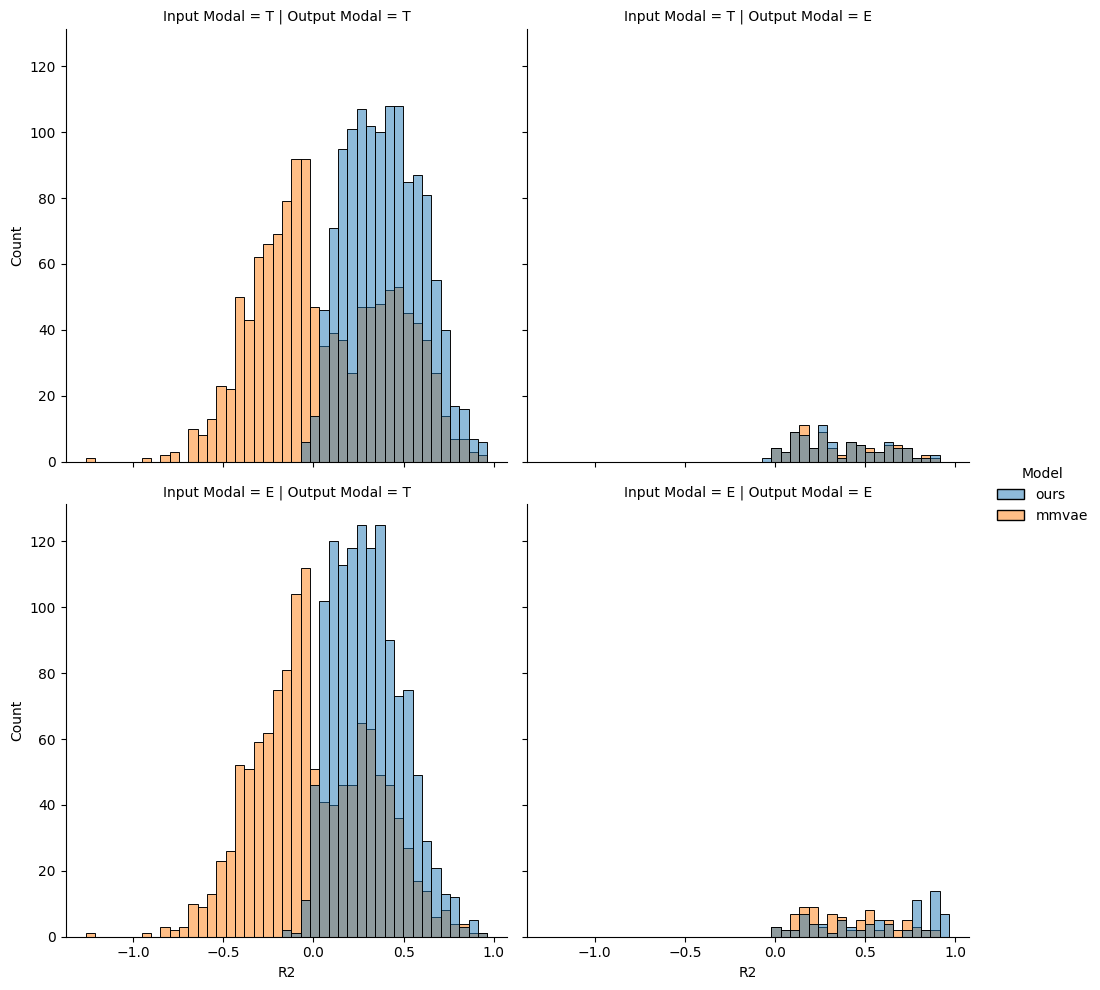

In [11]:
sns.displot(data = dataset_plots["patchseq"], x = "R2", row = "Input Modal", col = "Output Modal", hue = "Model")
plt.show()

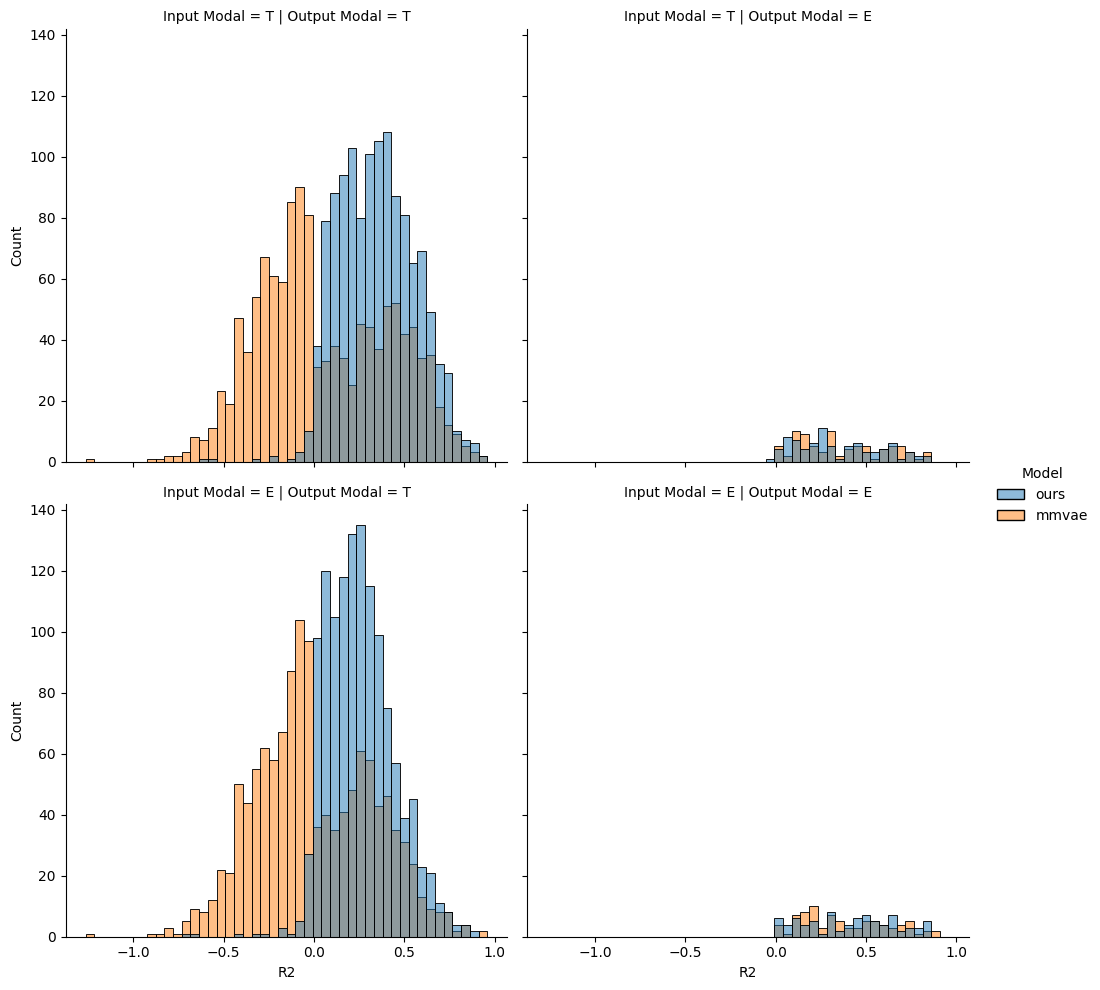

In [ ]:
sns.displot(data = dataset_plots["patchseq"], x = "R2", row = "Input Modal", col = "Output Modal", hue = "Model")
plt.show()

### PolyMNIST

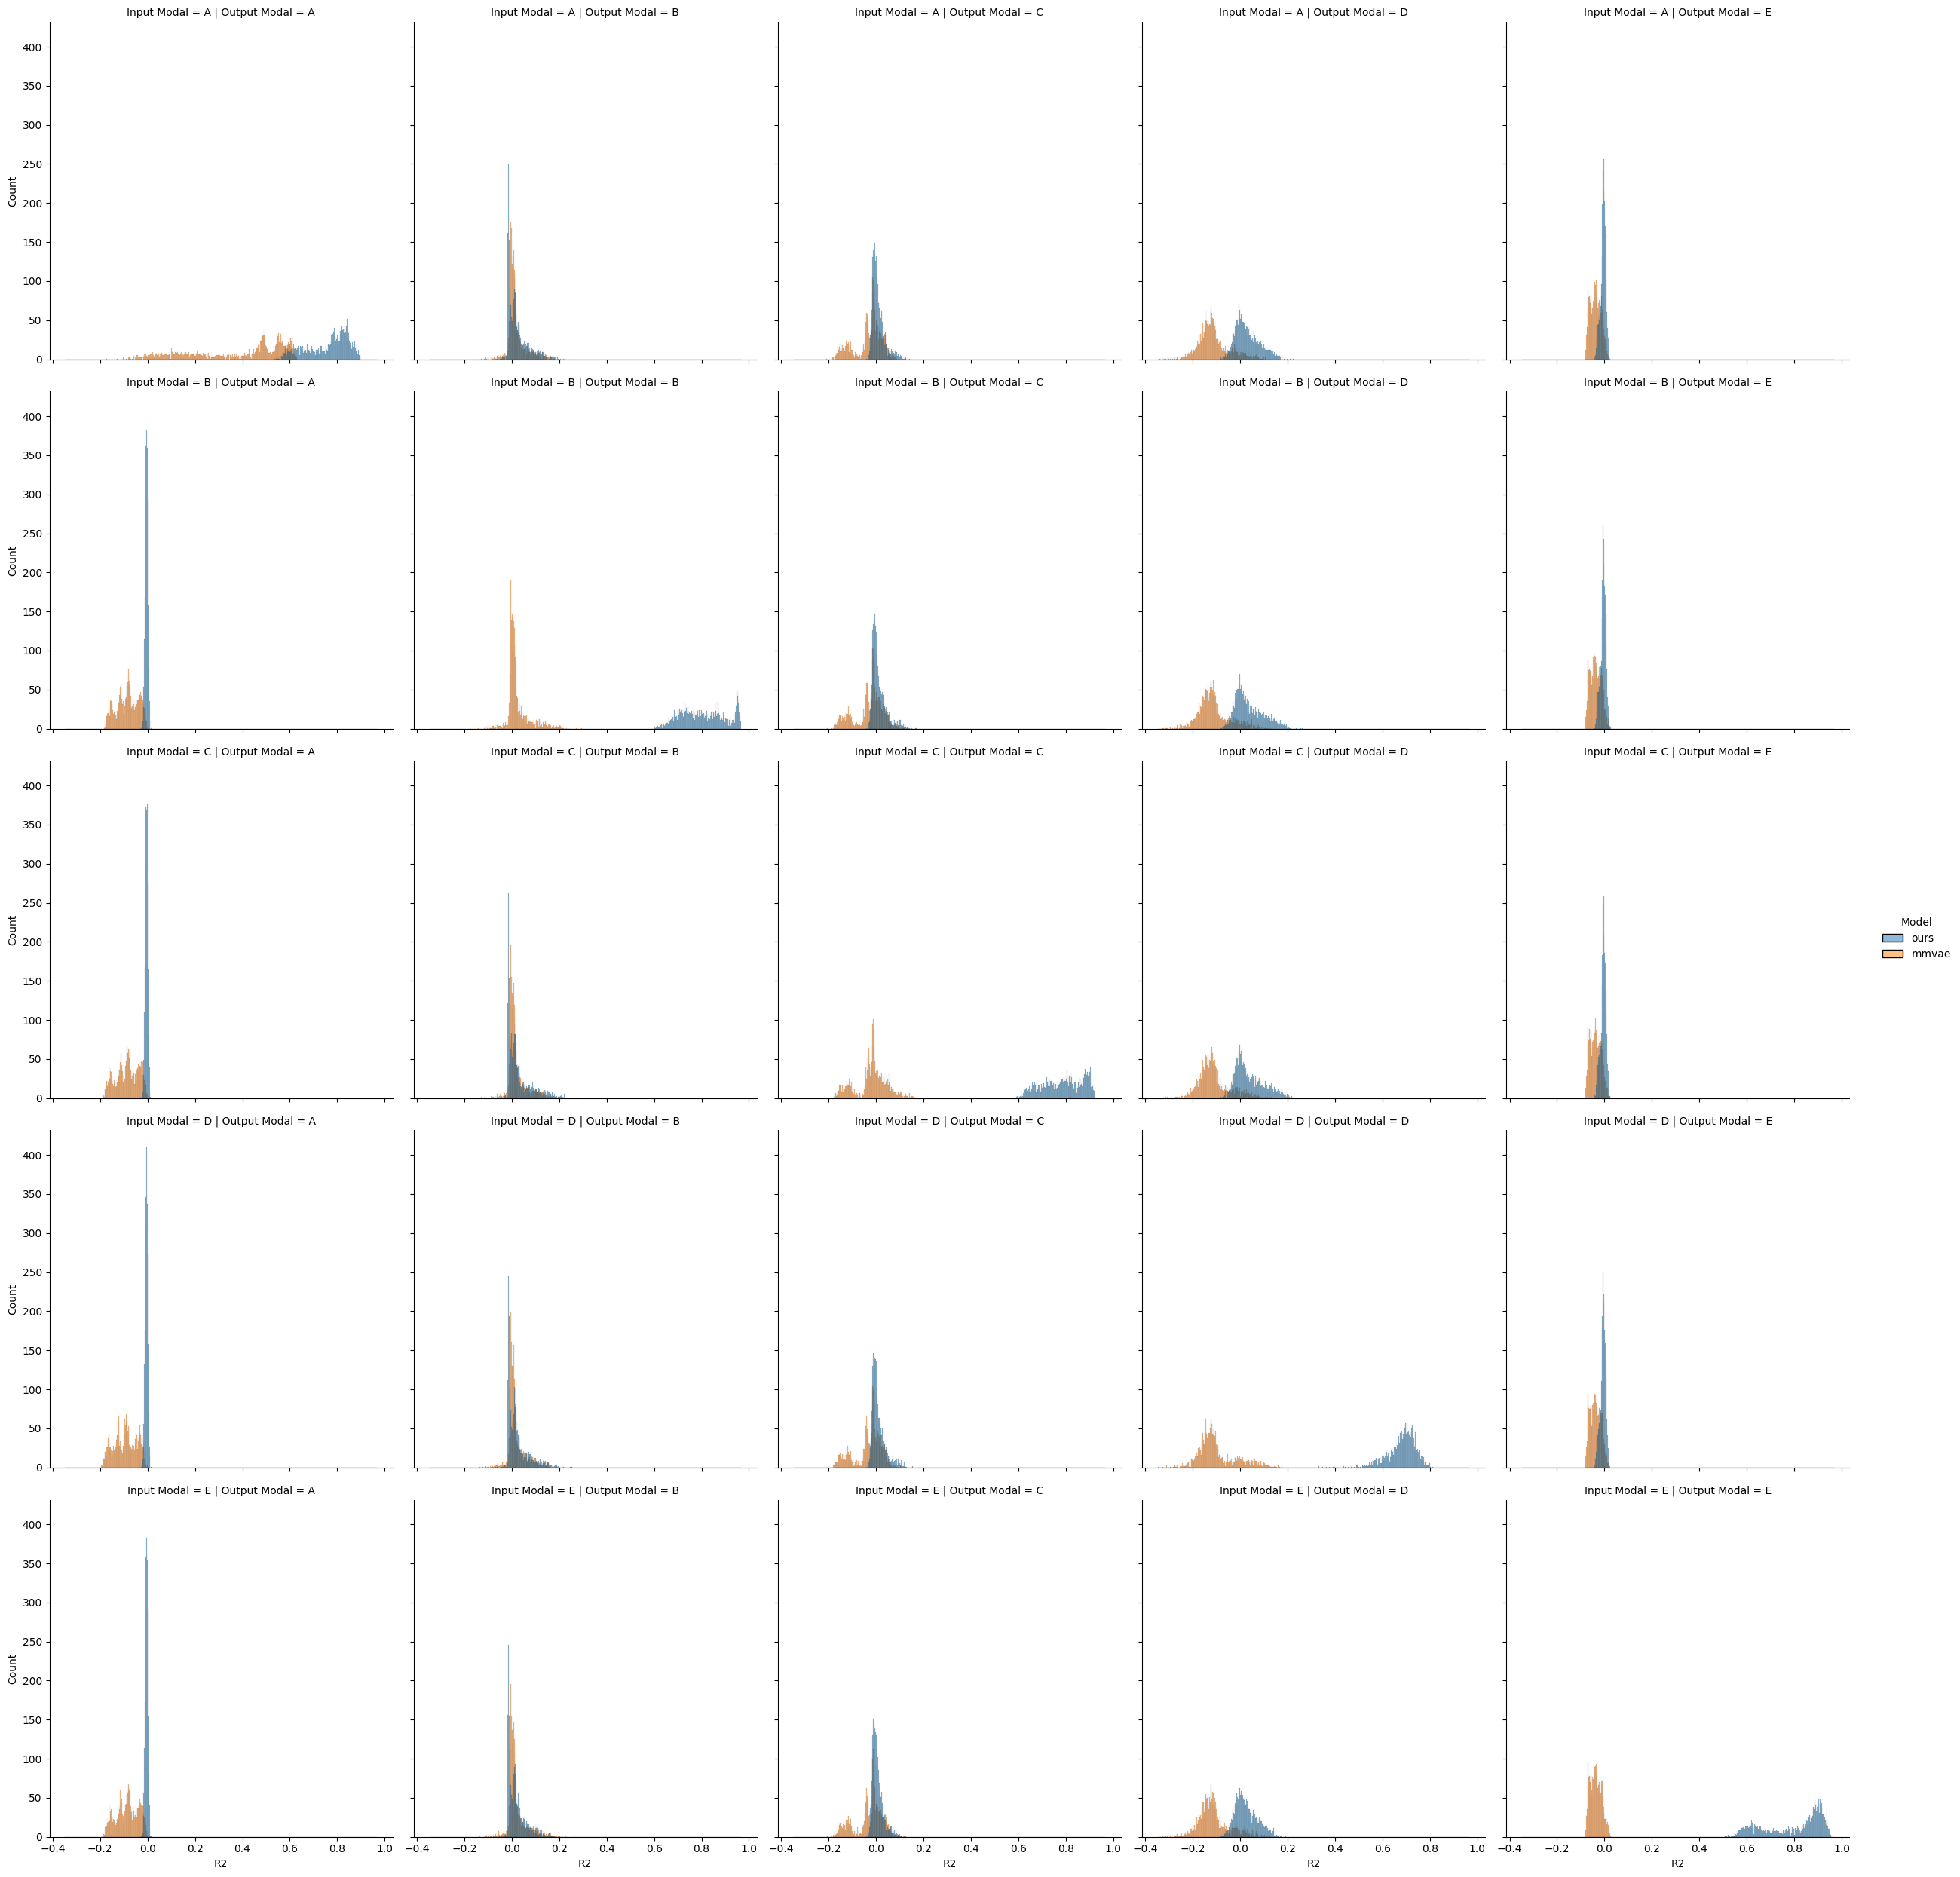

In [ ]:
sns.displot(data = dataset_plots["polymnist"], x = "R2", row = "Input Modal", col = "Output Modal", hue = "Model")
plt.show()

### CUB

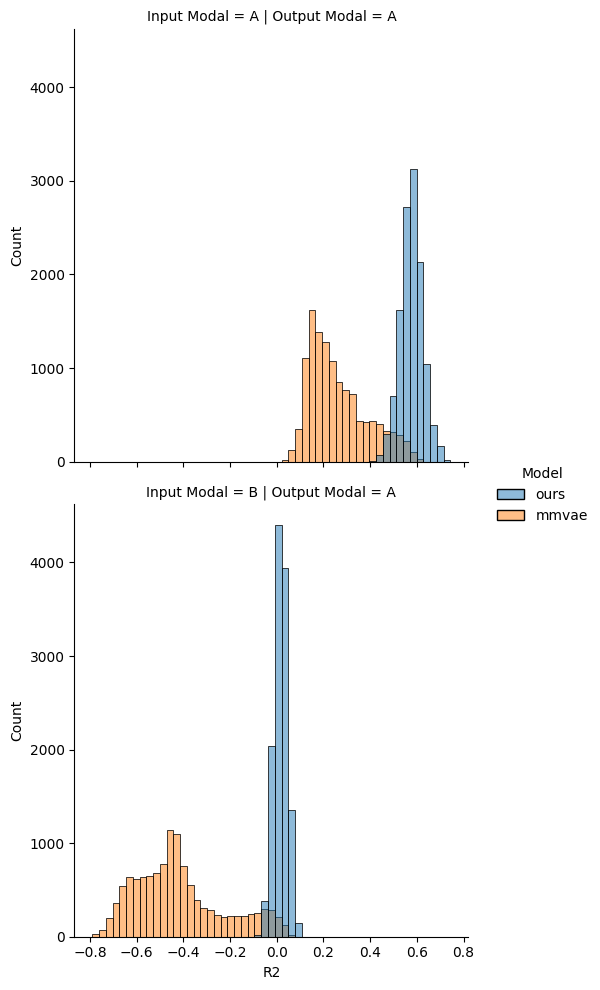

In [37]:
sns.displot(data = dataset_plots["cub"], x = "R2", row = "Input Modal", col = "Output Modal", hue = "Model")
plt.show()